In [1]:
from qiboopt.opt_class.opt_class import QUBO
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_frequencies(frequencies, qp, title="QAOA Result"):
    """Helper to plot a histogram of bitstring measurement frequencies."""
    bitstrings = list(frequencies.keys())
    counts     = list(frequencies.values())
    obj_values = [qp.evaluate_f([int(b) for b in bs]) for bs in bitstrings]

    # Sort by objective value for a cleaner plot
    sorted_pairs = sorted(zip(obj_values, bitstrings, counts))
    obj_values, bitstrings, counts = zip(*sorted_pairs)

    colours = ["tomato" if v == min(obj_values) else "steelblue" for v in obj_values]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(bitstrings, counts, color=colours)
    ax.set_xlabel("Bitstring")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

    # Annotate bars with their objective value
    for bar, obj in zip(bars, obj_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"f={obj:.2f}",
            ha="center", va="bottom", fontsize=8
        )

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="tomato",   label="Lowest energy (optimal)"),
        Patch(color="steelblue", label="Other states"),
    ])

    plt.tight_layout()
    plt.show()

In [3]:
# ─────────────────────────────────────────────
# 1. Basic QUBO Construction & Arithmetic
# ─────────────────────────────────────────────

Qdict = {(0, 0): 1.0, (0, 1): 0.5, (1, 1): -1.0}
qp = QUBO(0, Qdict)

print("Q matrix:", qp.Qdict)
print("Number of variables:", qp.n)

qp_scaled = qp * 2
print("Scaled Q:", qp_scaled.Qdict)

Qdict2 = {(0, 0): 2.0, (1, 1): 1.0}
qp2 = QUBO(1, Qdict2)
qp3 = qp + qp2
print("Combined Q:", qp3.Qdict)
print("Combined offset:", qp3.offset)

Q matrix: {(0, 0): 1.0, (0, 1): 0.5, (1, 1): -1.0}
Number of variables: 2
Scaled Q: {(0, 0): 2.0, (0, 1): 1.0, (1, 1): -2.0}
Combined Q: {(0, 0): 3.0, (0, 1): 0.5, (1, 1): 0.0}
Combined offset: 1


In [4]:
# ─────────────────────────────────────────────
# 2. Building & Inspecting a QAOA Circuit
# ─────────────────────────────────────────────

gammas = [0.5, 1.0]
betas  = [0.3, 0.8]

circuit = qp.qubo_to_qaoa_circuit(gammas, betas)
print(circuit.draw())


0: ─H─RZ─o────o─RX─RZ─o────o─RX─M─
1: ─H─RZ─X─RZ─X─RX─RZ─X─RZ─X─RX─M─
None


[Qibo 0.2.23|INFO|2026-02-23 13:37:41]: Using numpy backend on /CPU:0


Best cost found: -0.999
Optimised parameters: [5.35564301 5.76187803 2.49207591 6.96449787 1.98921472 2.71992698]
Most sampled solution: [0, 1]
Objective value: -1.0


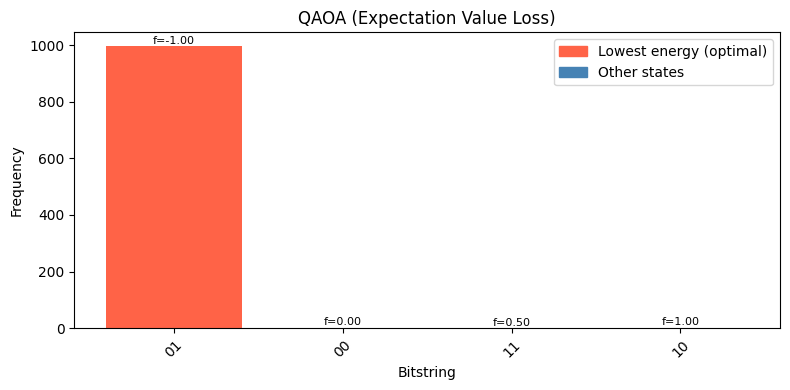

In [5]:
# ─────────────────────────────────────────────
# 3. Training QAOA (expectation value loss)
# ─────────────────────────────────────────────

best_cost, opt_params, extra_info, final_circuit, frequencies = qp.train_QAOA(
    p=3,
    nshots=1000,
    maxiter=50,
    method="cobyla",
    regular_loss=True,
)
print("Best cost found:", best_cost)
print("Optimised parameters:", opt_params)

best_bitstring = max(frequencies, key=frequencies.get)
best_x = [int(b) for b in best_bitstring]
print("Most sampled solution:", best_x)
print("Objective value:", qp.evaluate_f(best_x))

plot_frequencies(frequencies, qp, title="QAOA (Expectation Value Loss)")

XQAOA best cost: -0.4995
XQAOA most sampled solution: [0, 1]
XQAOA objective value: -1.0


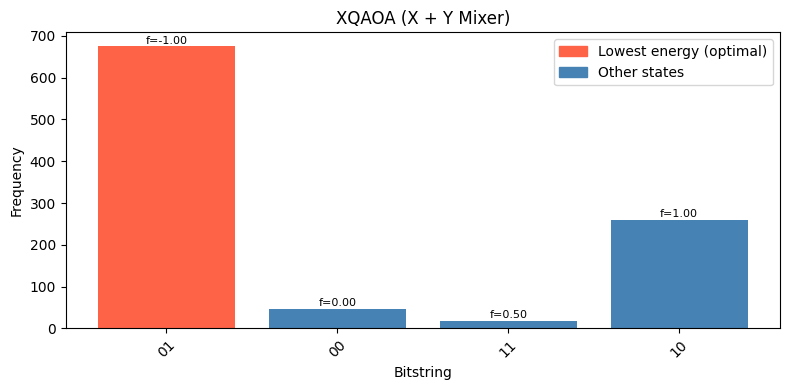

In [8]:
# ─────────────────────────────────────────────
# 4. Training XQAOA (adds Y-mixer via alphas)
# ─────────────────────────────────────────────

p = 3
gammas = np.random.rand(p) * 2 * np.pi
betas  = np.random.rand(p) * 2 * np.pi
alphas = np.random.rand(p) * 2 * np.pi

best_cost, opt_params, _, _, frequencies = qp.train_QAOA(
    gammas=gammas,
    betas=betas,
    alphas=alphas,
    nshots=1000,
    maxiter=30,
)
print("XQAOA best cost:", best_cost)

best_bitstring = max(frequencies, key=frequencies.get)
best_x = [int(b) for b in best_bitstring]
print("XQAOA most sampled solution:", best_x)
print("XQAOA objective value:", qp.evaluate_f(best_x))

plot_frequencies(frequencies, qp, title="XQAOA (X + Y Mixer)")

CVaR best cost: -1.0
CVaR most sampled solution: [0, 1]
CVaR objective value: -1.0


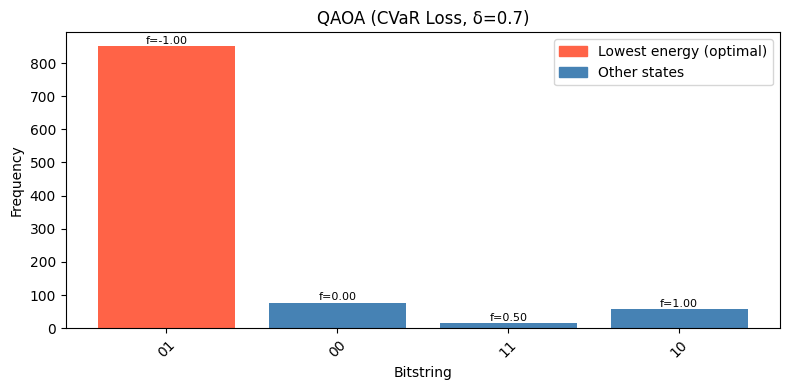

In [11]:
# ─────────────────────────────────────────────
# 5. CVaR Loss (focus on low-energy tail)
# ─────────────────────────────────────────────

best_cost, opt_params, _, _, frequencies = qp.train_QAOA(
    p=3,
    nshots=1000,
    maxiter=30,
    regular_loss=False,
    cvar_delta=0.7,
)
print("CVaR best cost:", best_cost)

best_bitstring = max(frequencies, key=frequencies.get)
best_x = [int(b) for b in best_bitstring]
print("CVaR most sampled solution:", best_x)
print("CVaR objective value:", qp.evaluate_f(best_x))

plot_frequencies(frequencies, qp, title="QAOA (CVaR Loss, δ=0.7)")